<a href="https://colab.research.google.com/github/SakshiMaholiya123/Machine-Learning/blob/project/01_Approval_Dynamics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
file=pd.read_csv('hdfc_loan_dataset_full_enriched - hdfc_loan_dataset_full_enriched.csv')

In [ ]:
file.head()

,Loan_ID,Bank,Customer_Name,Gender,Married,Dependents,Education,Employment_Status,Applicant_Income,Coapplicant_Income,...,Loan_to_Annual_Income,Customer_Sentiment,Religion,State,City,PIN_Code,Aadhaar_Synthetic,Phone_Number,Email,Occupation
0,HDFC100001,HDFC Bank,Rohan Verma,Male,No,2,Graduate,Salaried,56976,0,...,11.747,Positive,Hindu,Delhi,Dwarka,857743,6.940000e+11,9068671773,rohan.verma@example.in,Farmer
1,HDFC100002,HDFC Bank,Rohan Verma,Male,No,0,Graduate,Unemployed,1856,0,...,40.381,Negative,Hindu,Punjab,Ludhiana,863836,6.330000e+11,9990772625,rohan.verma@example.in,Civil Engineer
2,HDFC100003,HDFC Bank,Aditya Nair,Female,Yes,0,Graduate,Salaried,64553,0,...,3.082,Positive,Hindu,Maharashtra,Nagpur,834796,1.660000e+11,9195085016,aditya.nair@example.in,Medical Representative
3,HDFC100004,HDFC Bank,Ananya Joshi,Male,No,0,Graduate,Salaried,88450,0,...,0.621,Negative,Hindu,Gujarat,Vadodara,438590,5.528183e+10,9179335548,ananya.joshi@example.in,Marketing Executive
4,HDFC100005,HDFC Bank,Harpreet Singh,Male,Yes,3,Graduate,Self-Employed,9539,0,...,1.736,Neutral,Sikh,West Bengal,Kolkata,495224,1.560000e+11,9795137116,harpreet.singh@example.in,Shopkeeper


In [ ]:
file.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 47 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Loan_ID                      1000 non-null   object 
 1   Bank                         1000 non-null   object 
 2   Customer_Name                1000 non-null   object 
 3   Gender                       1000 non-null   object 
 4   Married                      1000 non-null   object 
 5   Dependents                   1000 non-null   int64  
 6   Education                    1000 non-null   object 
 7   Employment_Status            1000 non-null   object 
 8   Applicant_Income             1000 non-null   int64  
 9   Coapplicant_Income           1000 non-null   int64  
 10  Loan_Amount                  1000 non-null   int64  
 11  Loan_Term_Months             1000 non-null   int64  
 12  Credit_History               1000 non-null   int64  
 13  Property_Area      

In [ ]:
file['Loan_Status'].replace(['Approved', 'Rejected'],
                        [1,0], inplace=True)

/tmp/ipykernel_2960/1445346741.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  file['Loan_Status'].replace(['Approved', 'Rejected'],
/tmp/ipykernel_2960/1445346741.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  file['Loan_Status'].replace(['Approved', 'Rejected'],


In [ ]:
columns=['Applicant_Income','Annual_Household_Income','Debt_to_Income_Ratio','Loan_Status','CIBIL_Score']

In [ ]:
df=file[columns].copy()
df.reset_index()
df

,Applicant_Income,Annual_Household_Income,Debt_to_Income_Ratio,Loan_Status,CIBIL_Score
0,56976,683712,0.098,1,699
1,1856,22272,4.939,0,707
2,64553,774636,0.000,1,641
3,88450,1061400,0.301,1,677
4,9539,114468,0.000,1,594
...,...,...,...,...,...
995,44713,536556,0.116,1,707
996,70886,850632,0.284,0,561
997,24392,428748,0.966,1,725
998,64803,1907268,0.214,1,679


Mathematical Objective
Model Approval Behaviour as:
A = f(X)
where:
A = Approval Rate
X = Financial Indicator
Measure:
\frac{dA}{dX}
to determine the rate at which approvals change.


In [ ]:
debt=df['Debt_to_Income_Ratio']*df['Annual_Household_Income']
df['Annual_debt'] = np.where(df['Loan_Status']==0,'Not_Applicable',np.where(debt>df['Annual_Household_Income'],'Healthy','Managable'))
df

,Applicant_Income,Annual_Household_Income,Debt_to_Income_Ratio,Loan_Status,CIBIL_Score,Annual_debt
0,56976,683712,0.098,1,699,Managable
1,1856,22272,4.939,0,707,Not_Applicable
2,64553,774636,0.000,1,641,Managable
3,88450,1061400,0.301,1,677,Managable
4,9539,114468,0.000,1,594,Managable
...,...,...,...,...,...,...
995,44713,536556,0.116,1,707,Managable
996,70886,850632,0.284,0,561,Not_Applicable
997,24392,428748,0.966,1,725,Managable
998,64803,1907268,0.214,1,679,Managable


In [ ]:
df['approval_rate_particular']=np.where(debt>df['Annual_Household_Income'],25,np.where(debt<df['Annual_Household_Income'],70,50))
df

,Applicant_Income,Annual_Household_Income,Debt_to_Income_Ratio,Loan_Status,CIBIL_Score,Annual_debt,approval_rate_particular
0,56976,683712,0.098,1,699,Managable,70
1,1856,22272,4.939,0,707,Not_Applicable,25
2,64553,774636,0.000,1,641,Managable,70
3,88450,1061400,0.301,1,677,Managable,70
4,9539,114468,0.000,1,594,Managable,70
...,...,...,...,...,...,...,...
995,44713,536556,0.116,1,707,Managable,70
996,70886,850632,0.284,0,561,Not_Applicable,70
997,24392,428748,0.966,1,725,Managable,70
998,64803,1907268,0.214,1,679,Managable,70


In [ ]:
X=debt
A=df['approval_rate_particular']
dA_dX=np.gradient(A,X)
dA_dX

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:1245: RuntimeWarning: divide by zero encountered in divide
  a = -(dx2)/(dx1 * (dx1 + dx2))
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:1245: RuntimeWarning: invalid value encountered in divide
  a = -(dx2)/(dx1 * (dx1 + dx2))
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:1246: RuntimeWarning: divide by zero encountered in divide
  b = (dx2 - dx1) / (dx1 * dx2)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:1246: RuntimeWarning: invalid value encountered in divide
  b = (dx2 - dx1) / (dx1 * dx2)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:1247: RuntimeWarning: divide by zero encountered in divide
  c = dx1 / (dx2 * (dx1 + dx2))
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:1247: RuntimeWarning: invalid value encountered in divide
  c = dx1 / (dx2 * (dx1 + dx2))
/usr/local/lib/py

array([-1.04656926e-03, -1.45565494e-03, -6.23903325e-04,             nan,
        0.00000000e+00,  1.35525272e-20, -5.89274681e-05, -1.94238542e-04,
                   nan,  8.04291443e-04,  0.00000000e+00, -3.52365706e-19,
       -1.49077799e-19,  0.00000000e+00,  1.08420217e-19,  0.00000000e+00,
        1.28749008e-19, -2.71050543e-20,             nan,  4.33680869e-19,
        4.05826755e-04,  1.68109557e-04, -3.51097666e-03, -1.02376189e-04,
       -2.52713505e-04, -4.55183333e-04, -6.17270891e-05,  6.48959396e-04,
       -6.30481840e-04,  0.00000000e+00, -4.33680869e-19,             nan,
                   nan,             nan,  5.83083839e-04, -1.69666678e-05,
        0.00000000e+00,  7.38079589e-07,  9.62256533e-05, -5.83976294e-04,
       -1.07854573e-03, -1.77596984e-04, -4.33680869e-19,  2.71050543e-20,
        2.16840434e-19,  2.16840434e-19,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00, -2.16840434e-19, -6.03489571e-04, -1.06028391e-03,
        2.93013193e-04,  

Task 1
Perform exploratory analysis.
Study:
Income distribution
Credit score distribution
Approval distribution


In [ ]:
income=np.array(df['Applicant_Income'])
income

array([ 56976,   1856,  64553,  88450,   9539,  39184,  81223,      0,
        17675,  71409,  25553,  38126,  63115,  17960,  53684,  56092,
        29319,  10609,  38270,  43293,  48611,  15509,  56486,  97735,
        45050,  34900,   9381,   3000,  54597,  43481,  89792,  22973,
        92535,  39270,  55899,  33527,  28605,  33983,  23543, 129184,
         3000,  60010,  30506,  48860,  62285,  27205,  52863,  53000,
        91498,  47655,  92893,   1519,  80579,  94207,  27646,  23796,
        33925,  31372, 121176,  39035,  68621,  25617,  30088,  45832,
        81379,  29274,  65720,  66933,  36203,  52935,  15273,   5000,
        53105,  53066,  21455,  36438,  40206,  38127,  12104,      0,
        71887, 112111,   5000,   3000,  28345,   7914,  89966, 101852,
         7607,  62582,  62827,   3000,  21109,  45652,  60198,   8922,
        69615,  99781,  83511,   3000,  82923, 106418,  32371,  13956,
        86493,  74888,  43718,  98367,   7781,  59898,  79239,  92625,
      

In [ ]:
income_std=np.std(income)
income_std
income_mean=np.mean(income)
income_mean

np.float64(42430.057)

<Axes: ylabel='Count'>

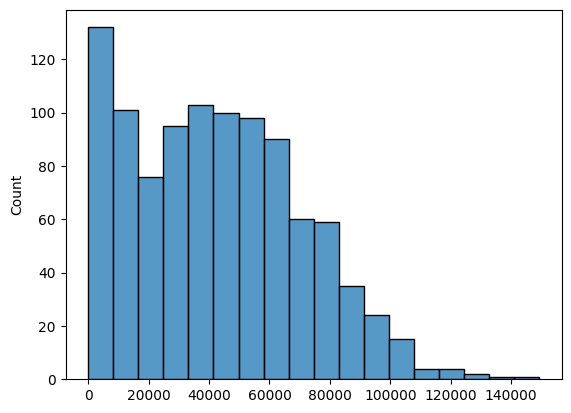

In [ ]:
sns.histplot(income)


In [ ]:
income_percentile=np.percentile(np.array(df['Applicant_Income']),[25,50,75])
income_percentile

array([18260.  , 40675.5 , 61037.25])

Credit score distribution

In [ ]:
cibil_mean=np.mean(np.array(df['CIBIL_Score']))
print(cibil_mean)
cibil_grad=np.array(df['CIBIL_Score'])
cibil_grad

653.013


array([699, 707, 641, 677, 594, 682, 693, 723, 593, 538, 659, 773, 811,
       598, 716, 719, 604, 637, 699, 759, 729, 609, 577, 715, 797, 638,
       669, 486, 737, 564, 673, 746, 758, 633, 636, 686, 522, 562, 579,
       663, 686, 637, 570, 643, 555, 781, 674, 842, 616, 757, 696, 687,
       718, 740, 617, 580, 696, 748, 619, 727, 684, 706, 655, 657, 525,
       602, 597, 561, 789, 634, 633, 712, 583, 722, 669, 680, 665, 717,
       615, 731, 727, 692, 707, 663, 527, 619, 772, 733, 739, 717, 595,
       654, 625, 710, 576, 630, 615, 631, 680, 553, 579, 750, 694, 612,
       703, 633, 755, 652, 678, 811, 690, 701, 560, 633, 762, 598, 726,
       666, 788, 657, 675, 672, 713, 680, 616, 734, 639, 645, 644, 606,
       676, 636, 704, 733, 672, 734, 597, 552, 641, 695, 642, 683, 564,
       522, 568, 551, 711, 654, 740, 683, 580, 704, 652, 623, 657, 662,
       664, 678, 529, 635, 609, 657, 625, 575, 704, 617, 468, 530, 593,
       605, 586, 689, 553, 640, 644, 623, 715, 646, 670, 599, 71

Text(0.5, 1.0, 'cibil score distribution')

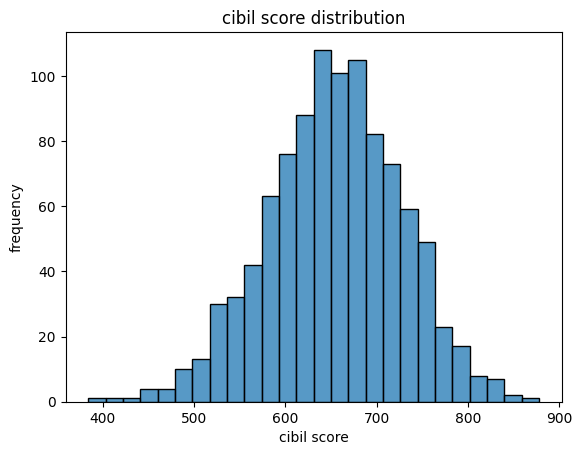

In [ ]:
sns.histplot(cibil_grad)
plt.xlabel('cibil score')
plt.ylabel('frequency')
plt.title('cibil score distribution')


In [ ]:
approved_loan=np.sum(df['Loan_Status']==1)
approved_loan

np.int64(653)

In [ ]:
rejected_loan=np.sum(df['Loan_Status']==0)
rejected_loan

np.int64(347)

Text(0, 0.5, 'frequency')

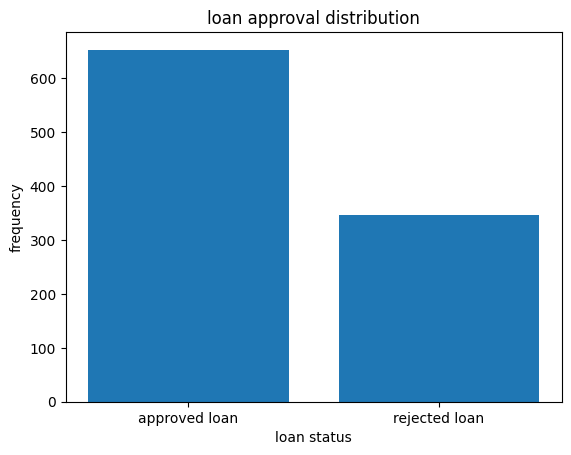

In [ ]:
plt.bar(['approved loan','rejected loan'],[approved_loan,rejected_loan])
plt.title('loan approval distribution')
plt.xlabel('loan status')
plt.ylabel('frequency')



In [ ]:
approval_rate=approved_loan/[approved_loan+rejected_loan]
approval_rate*100


array([65.3])

Task 2
Group applicants into bands.
Example:
Income Bands

Low Income
Middle Income
High Income
Premium Income



In [ ]:
min(df['Applicant_Income'])

0

In [ ]:
max(df['Applicant_Income'])

149266

In [ ]:
income = df['Applicant_Income']
p25=np.percentile(income,25)
p50=np.percentile(income,50)
p75=np.percentile(income,75)
p25,p50,p75

(np.float64(18260.0), np.float64(40675.5), np.float64(61037.25))

In [ ]:
df['income_bands']=np.where(income<p25,'low income',np.where(income<p50,'middle income',np.where(income<p75,'high income','premium income')))
df['income_bands']

,income_bands
0,high income
1,low income
2,premium income
3,premium income
4,low income
...,...
995,high income
996,premium income
997,middle income
998,premium income


Task 3
Calculate approval rate for each band.


In [ ]:
approval_rate_band=df.groupby('income_bands')['Loan_Status'].mean()*100
approval_rate_band

,Loan_Status
income_bands,
high income,80.0
low income,30.4
middle income,63.6
premium income,87.2


Task 4
Use numerical differentiation to calculate the rate of change in approval rates.
Example:
np.gradient(approval_rates)


In [ ]:
approval_rate_income=np.array(approval_rate_band)
approval_rate_income
rate_change_approval=np.gradient(approval_rate_income)
rate_change_approval

array([-49.6,  -8.2,  28.4,  23.6])

Task 5
Identify critical thresholds where approval rates increase or decrease sharply.


In [ ]:
critical_threshold_max=np.argmax(rate_change_approval)
critical_threshold_min=np.argmin(rate_change_approval)
print(critical_threshold_max)
print(critical_threshold_min)

2
0


Visualizations


Visual 1
Income Band vs Approval Rate


Text(0.5, 1.0, 'Income Band vs Approval Rate')

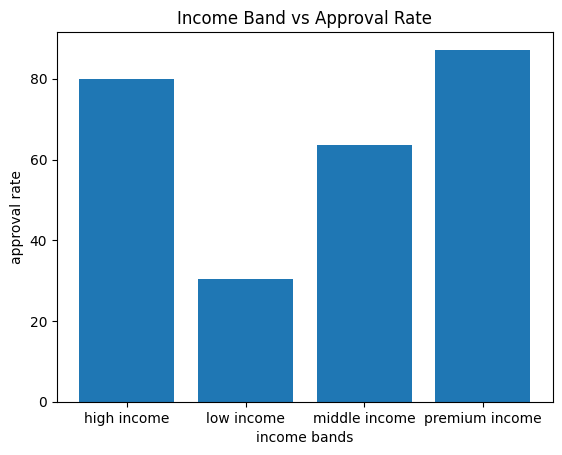

In [ ]:
plt.bar(approval_rate_band.index,approval_rate_band.values)
plt.xlabel('income bands')
plt.ylabel('approval rate')
plt.title('Income Band vs Approval Rate')


Visual 2
Credit Score Band vs Approval Rate


In [ ]:
cibil_score=pd.cut(np.array(df['CIBIL_Score']),bins=[300, 580, 670, 740, 850],labels=['poor','fair','good','best'])
cibil_score

['good', 'good', 'fair', 'good', 'fair', ..., 'good', 'poor', 'good', 'good', 'good']
Length: 1000
Categories (4, object): ['poor' < 'fair' < 'good' < 'best']

In [ ]:
cibil_score_band=df.groupby('CIBIL_Score')['Loan_Status'].mean()*100
cibil_score_band

,Loan_Status
CIBIL_Score,
384,0.0
412,0.0
422,0.0
445,0.0
446,0.0
...,...
835,100.0
838,100.0
842,100.0


Text(0.5, 1.0, 'credit score band vs approval rate')

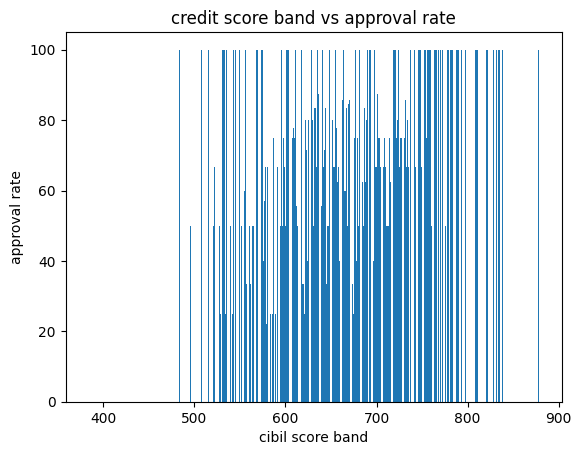

In [ ]:
plt.bar(cibil_score_band.index,cibil_score_band.values)
plt.xlabel('cibil score band')
plt.ylabel('approval rate')
plt.title('credit score band vs approval rate')



Visual 3
Rate of Change Curve


Text(0.5, 1.0, 'rate change approval')

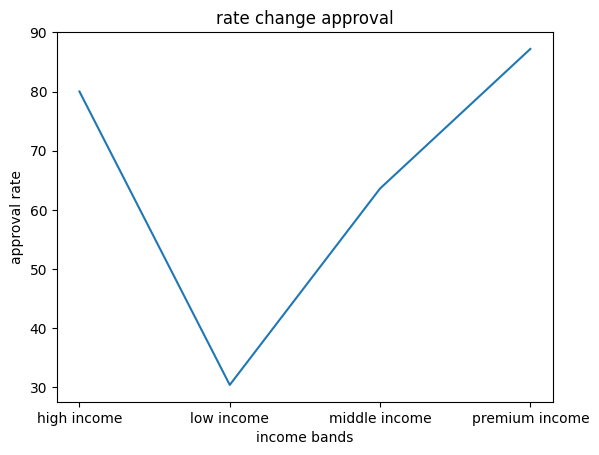

In [ ]:
plt.plot(approval_rate_band.index,approval_rate_band.values)
plt.xlabel('income bands')
plt.ylabel('approval rate')
plt.title('rate change approval')


Visual 4
Feature Sensitivity Comparison


In [ ]:
income_sensitivity=np.mean(np.abs(np.gradient(approval_rate_band)))
cibil_sensitivity=np.mean(np.abs(np.gradient(cibil_score_band)))
print(income_sensitivity)
print(cibil_sensitivity)


27.450000000000003
15.007350106034318


Text(0.5, 1.0, 'feature sensitivity comparison')

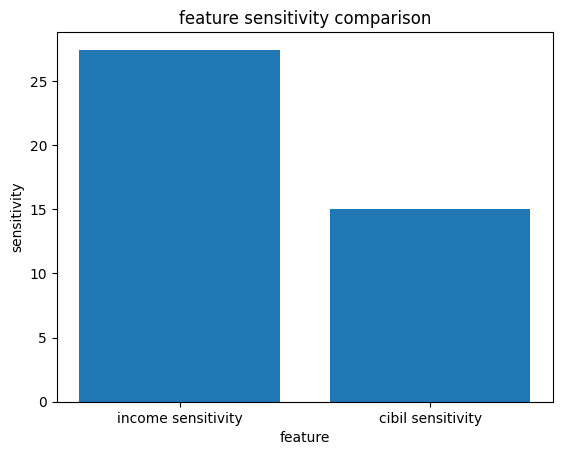

In [ ]:
plt.bar(['income sensitivity','cibil sensitivity'],[income_sensitivity,cibil_sensitivity])
plt.xlabel('feature')
plt.ylabel('sensitivity')
plt.title('feature sensitivity comparison')